In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as ticker
import matplotlib.colors
import geopandas as gpd
from unidecode import unidecode

In [6]:
# parameters
region_level = ["nuts3", "nuts4"]
year = 2017

**S1 - Description of the firm-level data**

In [3]:
# region codes
reg_codes = pd.read_csv("../data/oc01_2022_november/region_codes.csv", sep=";")
reg_codes = reg_codes.rename(columns={"jaras_kod":"nuts4_code", "jaras_nev":"nuts4_name", "megye_kod":"nuts3_code", "megye_nev":"nuts3_name"})
reg_codes = reg_codes.drop(reg_codes.index[-1])
reg_codes[f"{region_level[0]}_code"] = reg_codes[f"{region_level[0]}_code"].astype(int)
reg_codes[f"{region_level[1]}_code"] = reg_codes[f"{region_level[1]}_code"].astype(int)

In [4]:
# shape IN
map_df = gpd.read_file(f"../data/shape_files/{region_level[1]}_shape.geojson")

# OC emp data by regions
reg_emp = pd.read_csv(f"../data/oc17_2024_febr2/regional_descriptive_final_sample_{region_level[1]}_{year}.csv", sep=";")
reg_emp.columns.values[0] = "reg_code"
reg_emp["log_total_emp"] = np.log10(reg_emp["total_emp"])
reg_emp["log_total_firms"] = np.log10(reg_emp["total_firms"])

In [5]:
# join emp to map -- first region codes
map_df = pd.merge(
    map_df,
    reg_codes[[f"{region_level[1]}_code", f"{region_level[1]}_name"]].drop_duplicates(),
    left_on="region_name",
    right_on=f"{region_level[1]}_name",
    how="left"
)

# join emp to map -- second emp to map
map_df = pd.merge(
    map_df,
    reg_emp,
    left_on=f"{region_level[1]}_code",
    right_on="reg_code",
    how="left"
)

In [6]:
# pop dense data to plot_df for comparison
pop_df = pd.read_csv("../data/nuts_population_density_HUN.csv", sep=";")

In [7]:
def aggregate_popdata(df, focal_year, region_id):
    """aggregate pop density data from Gergo"""
    df = df[df["year"] == focal_year]
    df = df.groupby(region_id).agg(
        area = pd.NamedAgg("area", "sum"),
        pop = pd.NamedAgg("pop", "sum")
    ).reset_index()
    return df

In [8]:
# agg and calculate
agg_pop_df = aggregate_popdata(pop_df, focal_year=2017, region_id=region_level[1].lower())
agg_pop_df["popdense"] = agg_pop_df["pop"] / agg_pop_df["area"]
agg_pop_df["log_pop"] = np.log10(agg_pop_df["pop"])

# clean region names for merge
agg_pop_df[region_level[1].lower()] = agg_pop_df[region_level[1].lower()].apply(unidecode)

In [9]:
# combine
plot_df1 = pd.merge(
    map_df,
    agg_pop_df,
    left_on="region_name",
    right_on=region_level[1].lower(),
    how="left"
)

In [10]:
# shape IN -- NUTS3 version
map_df = gpd.read_file(f"../data/shape_files/{region_level[0]}_shape.geojson")

# OC emp data by regions
reg_emp = pd.read_csv(f"../data/oc17_2024_febr2/regional_descriptive_final_sample_{region_level[1]}_{year}.csv", sep=";")
reg_emp.columns.values[0] = "reg_code"
reg_emp["log_total_emp"] = np.log10(reg_emp["total_emp"])
reg_emp["log_total_firms"] = np.log10(reg_emp["total_firms"])

In [11]:
# shape IN
map_df = gpd.read_file(f"../data/shape_files/{region_level[0]}_shape.geojson")

# OC emp data by regions
reg_emp = pd.read_csv(f"../data/oc17_2024_febr2/regional_descriptive_final_sample_{region_level[0]}_{year}.csv", sep=";")
reg_emp.columns.values[0] = "reg_code"
reg_emp["log_total_emp"] = np.log10(reg_emp["total_emp"])
reg_emp["log_total_firms"] = np.log10(reg_emp["total_firms"])

In [12]:
# join emp to map -- first region codes
map_df = pd.merge(
    map_df,
    reg_codes[[f"{region_level[0]}_code", f"{region_level[0]}_name"]].drop_duplicates(),
    left_on="region_name",
    right_on=f"{region_level[0]}_name",
    how="left"
)

# join emp to map -- second emp to map
map_df = pd.merge(
    map_df,
    reg_emp,
    left_on=f"{region_level[0]}_code",
    right_on="reg_code",
    how="left"
)

In [13]:
# agg and calculate
agg_pop_df = aggregate_popdata(pop_df, focal_year=2017, region_id=region_level[0].lower())
agg_pop_df["popdense"] = agg_pop_df["pop"] / agg_pop_df["area"]
agg_pop_df["log_pop"] = np.log10(agg_pop_df["pop"])

# clean region names for merge
agg_pop_df[region_level[0].lower()] = agg_pop_df[region_level[0].lower()].apply(unidecode)

In [14]:
# combine
plot_df0 = pd.merge(
    map_df,
    agg_pop_df,
    left_on="region_name",
    right_on=region_level[0].lower(),
    how="left"
)

In [131]:
def plot_map(df, key_column, region_var, fontsize, cbar_text, bar_positions, bar_labels, shrink_value, ax=None):
    if ax is None:
        ax = plt.gca()

    # create common colormap
    cvals  = [df[key_column].min(), df[key_column].max()]
    colors = ["#FFFFFF","#15636A"]
    norm=plt.Normalize(min(cvals),max(cvals))
    tuples = list(zip(map(norm,cvals), colors))
    cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)

    # plot the map
    df.plot(
        column=key_column,
        cmap=cmap,
        edgecolor="None",
        ax=ax
    )

    # add boundaries
    df.boundary.plot(color="white", linewidth=0.125, ax=ax)
    ax.set_title(f"{region_var.upper()} regions", size=fontsize)

    # create colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.02, aspect=15, shrink=shrink_value)
    cbar.set_label(cbar_text, rotation=90, labelpad=15, fontsize=fontsize)
    ax.axis('off')
    cbar.set_ticks(bar_positions)
    cbar.set_ticklabels(bar_labels)

In [16]:
def keyvar_scatter(df, key_columns, fontsize, xtitle, ytitle, ax=None):
    if ax is None:
        ax = plt.gca()

    ax.scatter(df[key_columns[0]], df[key_columns[1]], color="#3F8990", alpha=0.8)
    ax.set_xlabel(xtitle, size=fontsize)
    ax.set_ylabel(ytitle, size=fontsize)
    ax.tick_params("x", labelsize=fontsize-5)
    ax.tick_params("y", labelsize=fontsize-5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

Text(-8, 12, 'D')

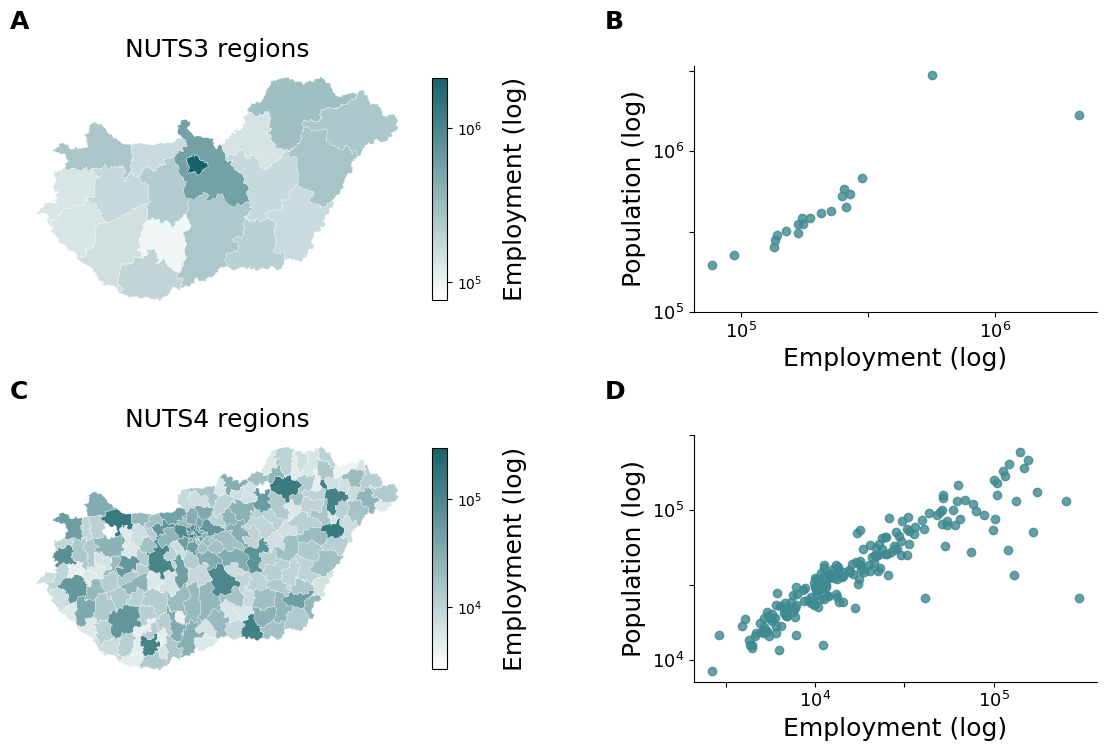

In [132]:
fig, ax = plt.subplots(2,2, figsize=(17,8), gridspec_kw={'width_ratios': [2, 1.05]})
fig.subplots_adjust(wspace=0.25, hspace=0.5)
fontsize=18

plot_map(plot_df0, key_column="log_total_emp", region_var=region_level[0], fontsize=fontsize, cbar_text="Employment (log)", bar_positions=[5,6], bar_labels=[r'$10^5$', r'$10^6$'], shrink_value=0.9, ax=ax[0,0])
keyvar_scatter(plot_df0, key_columns=["log_total_emp", "log_pop"], xtitle="Employment (log)", ytitle="Population (log)", fontsize=fontsize, ax=ax[0,1])
ax[0,1].set_xticks([5, 5.5, 6])
ax[0,1].set_xticklabels([r'$10^5$', "", r'$10^6$'])
ax[0,1].set_yticks([5, 5.5, 6, 6.5])
ax[0,1].set_yticklabels([r'$10^5$', "", r'$10^6$', ""])

plot_map(plot_df1, key_column="log_total_emp", region_var=region_level[1], fontsize=fontsize, cbar_text="Employment (log)", bar_positions=[4,5], bar_labels=[r'$10^4$', r'$10^5$'], shrink_value=0.9, ax=ax[1,0])
keyvar_scatter(plot_df1, key_columns=["log_total_emp", "log_pop"], xtitle="Employment (log)", ytitle="Population (log)", fontsize=fontsize, ax=ax[1,1])
ax[1,1].set_xticks([3.5, 4, 4.5, 5])
ax[1,1].set_xticklabels(["", r'$10^4$', "", r'$10^5$'])
ax[1,1].set_yticks([4, 4.5, 5, 5.5])
ax[1,1].set_yticklabels([r'$10^4$', "", r'$10^5$', ""])


# subplot title
ax[0,0].annotate("A", xy=(0,1.1), xycoords='axes fraction', xytext=(-8,12), textcoords='offset pixels', weight='bold', size=fontsize)
ax[0,1].annotate("B", xy=(-0.2,1.1), xycoords='axes fraction', xytext=(-8,12), textcoords='offset pixels', weight='bold', size=fontsize)
ax[1,0].annotate("C", xy=(0,1.1), xycoords='axes fraction', xytext=(-8,12), textcoords='offset pixels', weight='bold', size=fontsize)
ax[1,1].annotate("D", xy=(-0.2,1.1), xycoords='axes fraction', xytext=(-8,12), textcoords='offset pixels', weight='bold', size=fontsize)

# plt.savefig(f"../figures/si_map_emp_combined.png", dpi=300, bbox_inches='tight', facecolor="white")

Text(-8, 12, 'B')

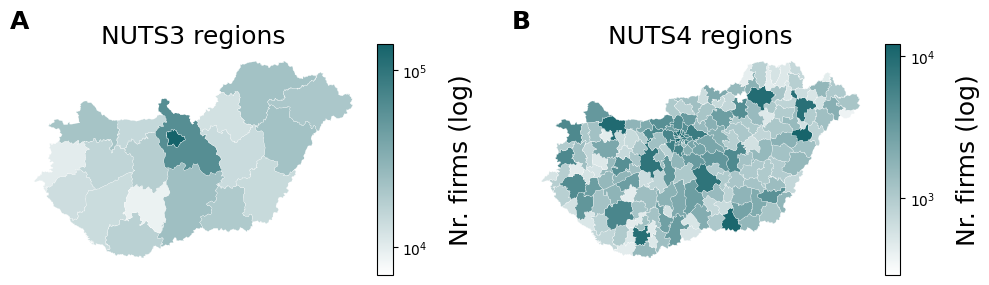

In [134]:
# map of number of firms
fig, ax = plt.subplots(1,2, figsize=(12,6))
fig.subplots_adjust(wspace=0.2)
fontsize=18

# NUTS3
#plot_df0.plot(column="log_total_firms", ax=ax[0])
plot_map(
    plot_df0,
    key_column="log_total_firms",
    region_var=region_level[0],
    fontsize=fontsize,
    cbar_text="Nr. firms (log)",
    bar_positions=[4,5],
    bar_labels=[r'$10^4$', r'$10^5$'],
    shrink_value=0.5,
    ax=ax[0]
)

# NUTS4
#plot_df1.plot(column="log_total_firms", ax=ax[1])
plot_map(
    plot_df1,
    key_column="log_total_firms",
    region_var=region_level[1],
    fontsize=fontsize,
    cbar_text="Nr. firms (log)",
    bar_positions=[3,4],
    bar_labels=[r'$10^3$', r'$10^4$'],
    shrink_value=0.5,
    ax=ax[1]
)

# subplot title
ax[0].annotate("A", xy=(0,1.05), xycoords='axes fraction', xytext=(-8,12), textcoords='offset pixels', weight='bold', size=fontsize)
ax[1].annotate("B", xy=(-0.015,1.05), xycoords='axes fraction', xytext=(-8,12), textcoords='offset pixels', weight='bold', size=fontsize)

# plt.savefig(f"../figures/si_map_firms.png", dpi=300, bbox_inches='tight', facecolor="white")

In [43]:
# distribution of firms / employment across industries
ind_df = pd.read_csv(f"../data/oc17_2024_febr2/industries_descriptive_final_sample_nace3d_2017.csv", sep=";")

In [46]:
# agg for visualization
ind_df["nace2d"] = ind_df["nace3d"] // 10
ind_df2 = ind_df.groupby(["nace2d"]).agg(
    total_emp = pd.NamedAgg("total_emp", "sum"),
    total_firms = pd.NamedAgg("total_firms", "sum")
).reset_index()

Text(-8, 12, 'B')

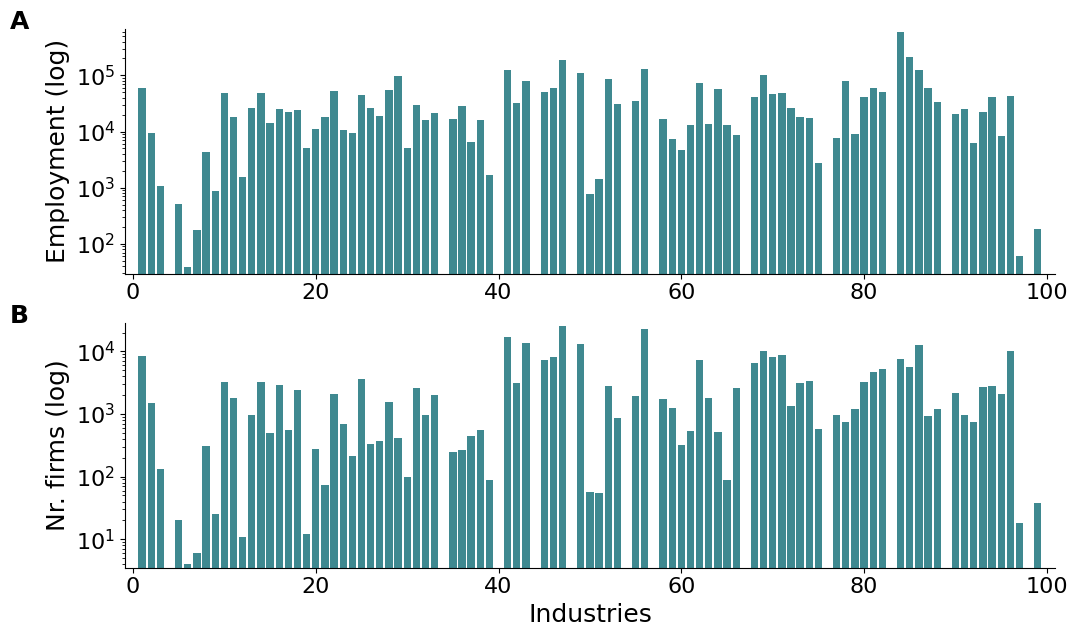

In [88]:
fig, ax = plt.subplots(2,1, figsize=(12,7))
fontsize=18

# employment
ax[0].bar(ind_df["nace2d"], ind_df["total_emp"], color="#3F8990")
ax[0].semilogy()
ax[0].set_ylabel("Employment (log)", size=fontsize)
ax[0].tick_params("x", labelsize=(fontsize-2))
ax[0].tick_params("y", labelsize=(fontsize-2))
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].margins(0.015, tight=True)


# firms
ax[1].bar(ind_df["nace2d"], ind_df["total_firms"], color="#3F8990")
ax[1].semilogy()
ax[1].set_xlabel("Industries", size=fontsize)
ax[1].set_ylabel("Nr. firms (log)", size=fontsize)
ax[1].tick_params("x", labelsize=(fontsize-2))
ax[1].tick_params("y", labelsize=(fontsize-2))
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].margins(0.015, tight=True)

# subplot title
ax[0].annotate("A", xy=(-0.115,0.95), xycoords='axes fraction', xytext=(-8,12), textcoords='offset pixels', weight='bold', size=fontsize)
ax[0].annotate("B", xy=(-0.115,-0.25), xycoords='axes fraction', xytext=(-8,12), textcoords='offset pixels', weight='bold', size=fontsize)

# plt.savefig(f"../figures/si_industries_emp_firms.png", dpi=300, bbox_inches='tight', facecolor="white")

**S2 - Key variables and alternative measures**

In [8]:
def matrix_represantation(df, key_columns, sort_matrix, heatmap, fontsize, title_text, cmap, cbar_label, ax=None):
    """matrix or pivot table representation of our key variables"""
    table = df[key_columns]

    # undirected to directed -- to have a full matrix
    table2 = table.copy().rename(columns={"ind1": "ind2", "ind2": "ind1"})
    table2 = table2[key_columns]
    table = pd.concat([table, table2])

    # pivot transformation
    table = pd.pivot_table(table,
        values=key_columns[2],
        index=key_columns[0],
        columns=key_columns[1],
        aggfunc=np.max,
        margins=True,
        margins_name='total')

    # option to sort the matrix
    if sort_matrix == True:
        table = table\
            .sort_values(by=["total"], ascending=False, axis=0)\
            .sort_values(by=["total"], ascending=False, axis=1)
    else:
        table = table
    
    table = table.drop(["total"], axis=1).drop(["total"], axis=0)
    
    # option to keep the table or create heatmap
    if heatmap==False:
        return table
    else:
        if ax is None:
            ax = plt.gca()
        sns.heatmap(
            table,
            cbar=True,
            cmap=cmap,
            ax=ax
        )
        ax.figure.axes[-1].set_ylabel(cbar_label, size=fontsize-5)
        ax.set_xlabel("Industry", size=fontsize)
        ax.set_ylabel("Industry", size=fontsize)
        ax.set_title(title_text, size=fontsize)
        ax.yaxis.set_tick_params(rotation=0, labelbottom=True)
        #ax.set_xticklabels("")
        #ax.set_yticklabels("")
        ax.tick_params(left = False, bottom = False)

In [9]:
# KDE plots to illustrate distribution
def density_plot(df, key_column, colorway, xlabel_text, fontsize, ax=None):
    if ax is None:
        ax = plt.gca()

    sns.kdeplot(data=df,
        x=key_column,
        fill=True,
        color=colorway,
        linewidth=2.5,
        log_scale=False,
        ax=ax)
    
    ax.set_xlabel(xlabel_text, size=fontsize)
    ax.set_ylabel("Density", size=fontsize)
    ax.tick_params("x", labelsize=(fontsize-5))
    ax.tick_params("y", labelsize=(fontsize-5))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

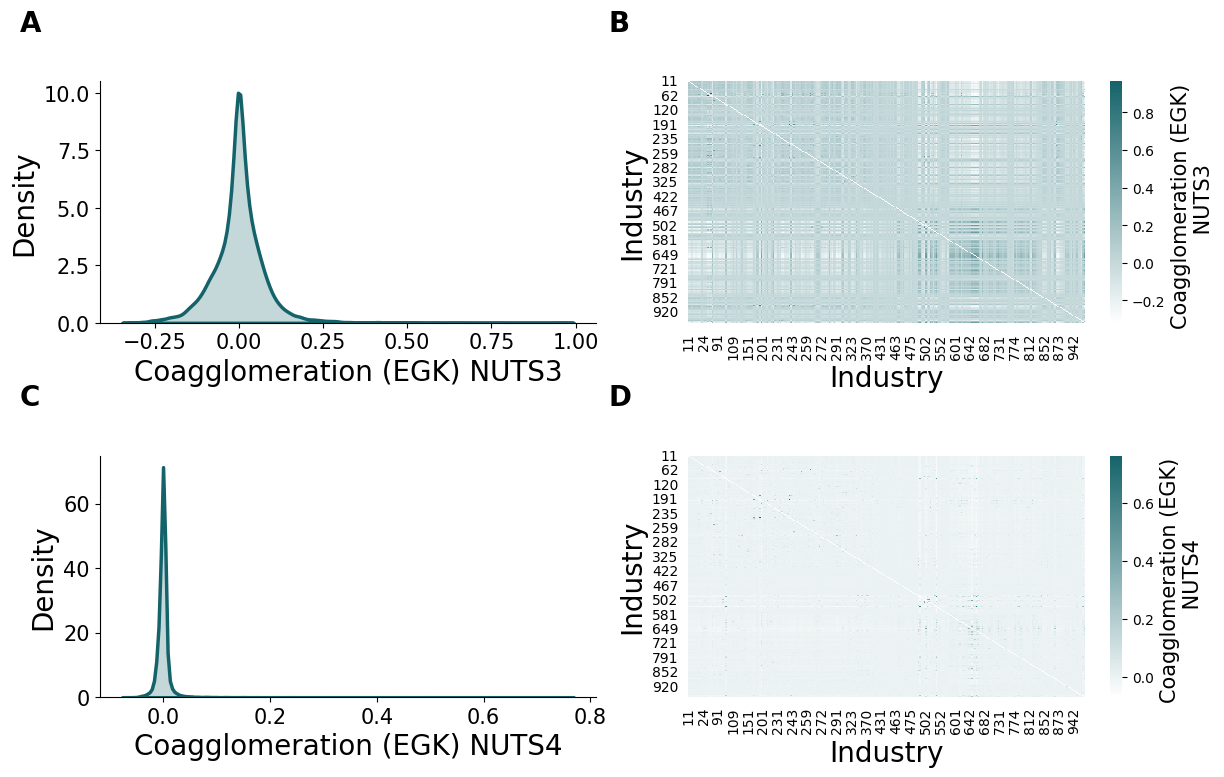

In [21]:
fig = plt.figure(figsize=(14, 8))
ax = [0]*4
gs = GridSpec(2,2, figure=fig)
ax[0] = fig.add_subplot(gs[0,0])
ax[1] = fig.add_subplot(gs[0,1])
ax[2] = fig.add_subplot(gs[1,0])
ax[3] = fig.add_subplot(gs[1,1])
fig.subplots_adjust(hspace=0.55, wspace=0.185) 

textsize = 20
key_var = "egk_coagg"
region_levels = ["nuts3", "nuts4"]

# NUST3
reg_df = pd.read_csv(f"../data/oc15_2023_dec/04oc_data_{region_levels[0]}_{year}.csv", sep=";")
reg_df = reg_df[reg_df["ind1"] < reg_df["ind2"]]

# colormap
cvals  = [reg_df[key_var].min(), reg_df[key_var].max()]
colors = ["#FFFFFF","#15636A"]
norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)

density_plot(
    reg_df,
    key_column=key_var,
    colorway=colors[1],
    xlabel_text="Coagglomeration (EGK) NUTS3",
    fontsize=textsize,
    ax=ax[0]
)

matrix_represantation(
    reg_df,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap=cmap,
    cbar_label="Coagglomeration (EGK) \n NUTS3",
    ax=ax[1]
)

# NUTS4
reg_df = pd.read_csv(f"../data/oc15_2023_dec/04oc_data_{region_levels[1]}_{year}.csv", sep=";")
reg_df = reg_df[reg_df["ind1"] < reg_df["ind2"]]

# colormap
cvals  = [reg_df[key_var].min(), reg_df[key_var].max()]
colors = ["#FFFFFF","#15636A"]
norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)

density_plot(
    reg_df,
    key_column=key_var,
    colorway=colors[1],
    xlabel_text="Coagglomeration (EGK) NUTS4",
    fontsize=textsize,
    ax=ax[2]
)

matrix_represantation(
    reg_df,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap=cmap,
    cbar_label="Coagglomeration (EGK) \n NUTS4",
    ax=ax[3]
)

# subplot title
for a, label in zip(ax, ['A','B','C','D']):
    a.annotate(label.upper(), xy=(0,1), xycoords='axes fraction', xytext=(-80,50), textcoords='offset pixels', weight='bold', size=textsize)

# plt.savefig(f"../figures/si_{key_var}_distributions.png", dpi=300, bbox_inches='tight', facecolor="white")

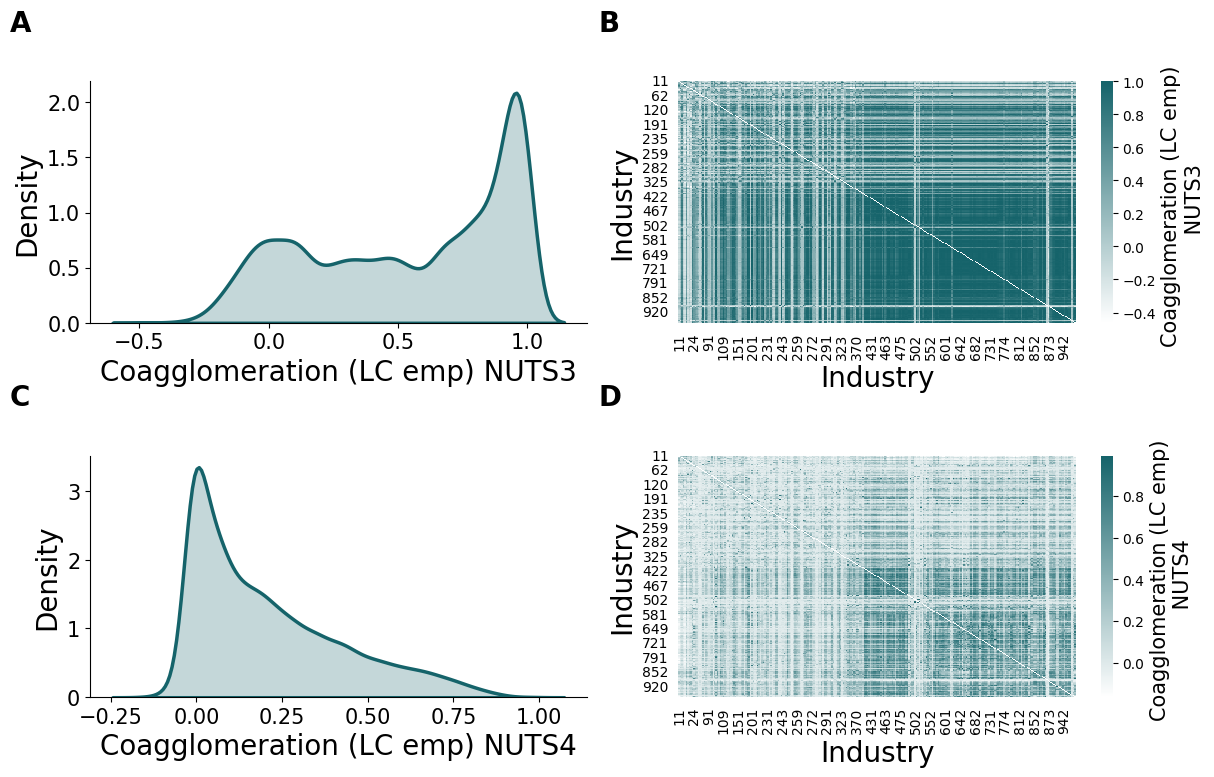

In [13]:
fig = plt.figure(figsize=(14, 8))
ax = [0]*4
gs = GridSpec(2,2, figure=fig)
ax[0] = fig.add_subplot(gs[0,0])
ax[1] = fig.add_subplot(gs[0,1])
ax[2] = fig.add_subplot(gs[1,0])
ax[3] = fig.add_subplot(gs[1,1])
fig.subplots_adjust(hspace=0.55, wspace=0.185) 

textsize = 20
key_var = "coagg_porter_emp"
region_levels = ["nuts3", "nuts4"]

# colormap
cvals  = [reg_df[key_var].min(), reg_df[key_var].max()]
colors = ["#FFFFFF","#15636A"]
norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)

# NUST3
reg_df = pd.read_csv(f"../data/oc15_2023_dec/04oc_data_{region_levels[0]}_{year}.csv", sep=";")
reg_df = reg_df[reg_df["ind1"] < reg_df["ind2"]]

density_plot(
    reg_df,
    key_column=key_var,
    colorway=colors[1],
    xlabel_text="Coagglomeration (LC emp) NUTS3",
    fontsize=textsize,
    ax=ax[0]
)

matrix_represantation(
    reg_df,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap=cmap,
    cbar_label="Coagglomeration (LC emp) \n NUTS3",
    ax=ax[1]
)


# NUTS4
reg_df = pd.read_csv(f"../data/oc15_2023_dec/04oc_data_{region_levels[1]}_{year}.csv", sep=";")
reg_df = reg_df[reg_df["ind1"] < reg_df["ind2"]]

density_plot(
    reg_df,
    key_column=key_var,
    colorway=colors[1],
    xlabel_text="Coagglomeration (LC emp) NUTS4",
    fontsize=textsize,
    ax=ax[2]
)

matrix_represantation(
    reg_df,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap=cmap,
    cbar_label="Coagglomeration (LC emp) \n NUTS4",
    ax=ax[3]
)

# subplot title
for a, label in zip(ax, ['A','B','C','D']):
    a.annotate(label.upper(), xy=(0,1), xycoords='axes fraction', xytext=(-80,50), textcoords='offset pixels', weight='bold', size=textsize)

# plt.savefig(f"../figures/si_{key_var}_distributions.png", dpi=300, bbox_inches='tight', facecolor="white")

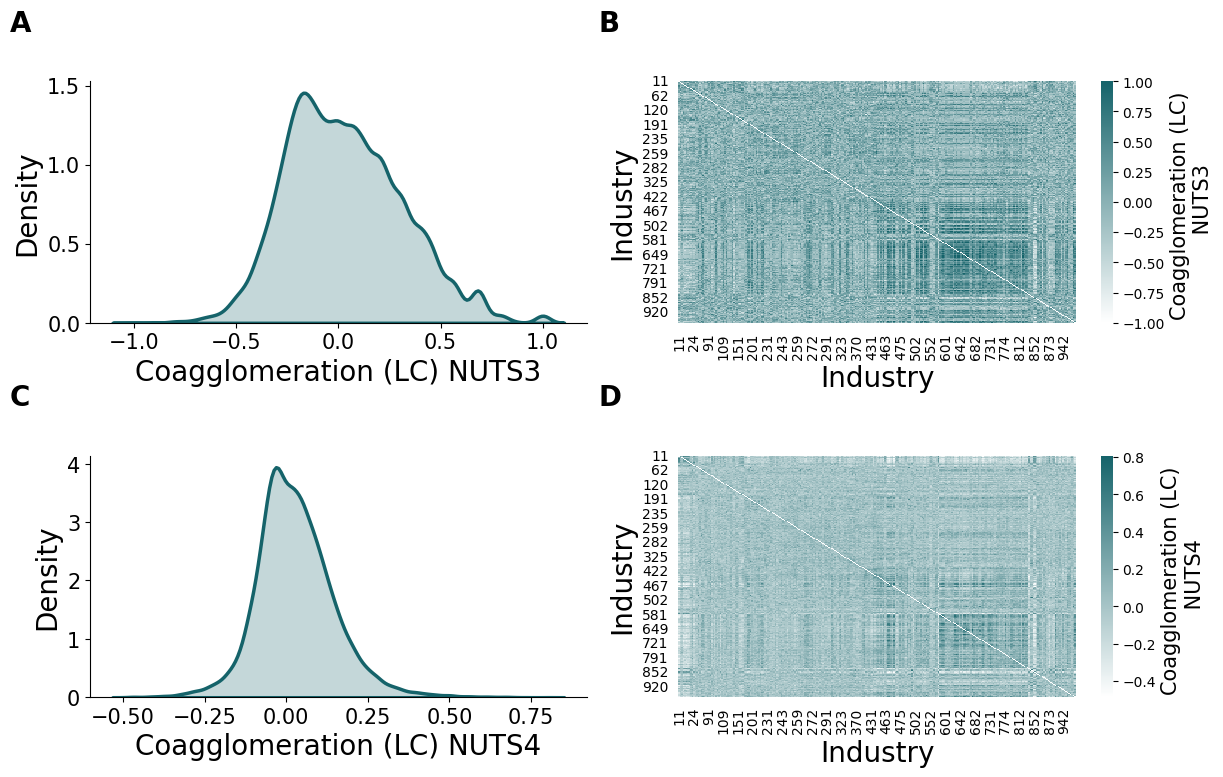

In [25]:
fig = plt.figure(figsize=(14, 8))
ax = [0]*4
gs = GridSpec(2,2, figure=fig)
ax[0] = fig.add_subplot(gs[0,0])
ax[1] = fig.add_subplot(gs[0,1])
ax[2] = fig.add_subplot(gs[1,0])
ax[3] = fig.add_subplot(gs[1,1])
fig.subplots_adjust(hspace=0.55, wspace=0.185) 

textsize = 20
key_var = "coagg_porter_rca01"
region_levels = ["nuts3", "nuts4"]

# colormap
cvals  = [reg_df[key_var].min(), reg_df[key_var].max()]
colors = ["#FFFFFF","#15636A"]
norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)

# NUST3
reg_df = pd.read_csv(f"../data/oc15_2023_dec/04oc_data_{region_levels[0]}_{year}.csv", sep=";")
reg_df = reg_df[reg_df["ind1"] < reg_df["ind2"]]

density_plot(
    reg_df,
    key_column=key_var,
    colorway=colors[1],
    xlabel_text="Coagglomeration (LC) NUTS3",
    fontsize=textsize,
    ax=ax[0]
)

matrix_represantation(
    reg_df,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap=cmap,
    cbar_label="Coagglomeration (LC) \n NUTS3",
    ax=ax[1]
)


# NUTS4
reg_df = pd.read_csv(f"../data/oc15_2023_dec/04oc_data_{region_levels[1]}_{year}.csv", sep=";")
reg_df = reg_df[reg_df["ind1"] < reg_df["ind2"]]

density_plot(
    reg_df,
    key_column=key_var,
    colorway=colors[1],
    xlabel_text="Coagglomeration (LC) NUTS4",
    fontsize=textsize,
    ax=ax[2]
)

matrix_represantation(
    reg_df,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap=cmap,
    cbar_label="Coagglomeration (LC) \n NUTS4",
    ax=ax[3]
)

# subplot title
for a, label in zip(ax, ['A','B','C','D']):
    a.annotate(label.upper(), xy=(0,1), xycoords='axes fraction', xytext=(-80,50), textcoords='offset pixels', weight='bold', size=textsize)

# plt.savefig(f"../figures/si_{key_var}_distributions.png", dpi=300, bbox_inches='tight', facecolor="white")

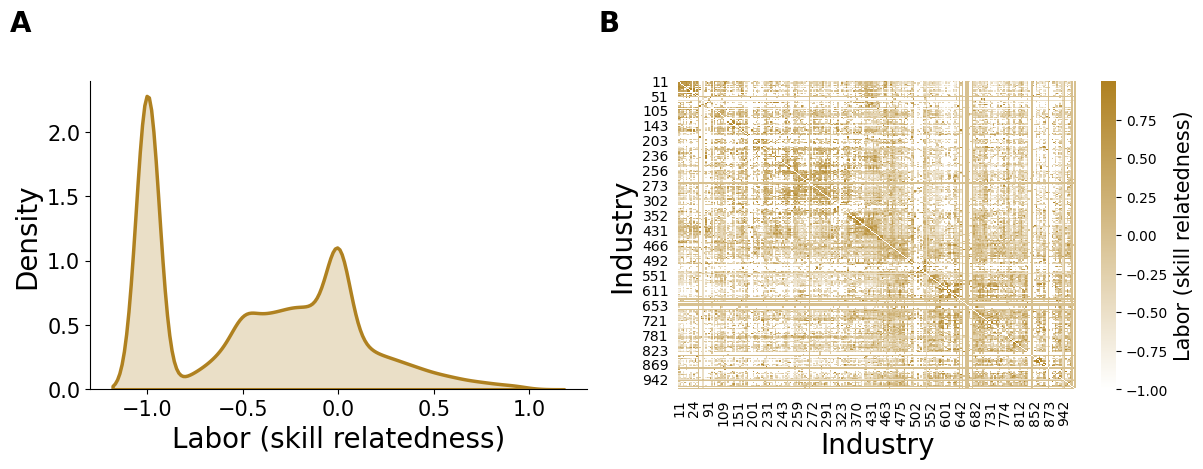

In [27]:
fig = plt.figure(figsize=(14, 4))
ax = [0]*2
gs = GridSpec(1,2, figure=fig)
ax[0] = fig.add_subplot(gs[0,0])
ax[1] = fig.add_subplot(gs[0,1])
fig.subplots_adjust(hspace=0.55, wspace=0.185) 

textsize = 20
key_var = "sr_norm"
region_levels = ["nuts3", "nuts4"]

# colormap
cvals  = [-1, 1]
colors = ["#FFFFFF","#AF8120"]
norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)

# NUST3
reg_df = pd.read_csv(f"../data/oc15_2023_dec/04oc_data_{region_levels[0]}_{year}.csv", sep=";")
reg_df = reg_df[reg_df["ind1"] < reg_df["ind2"]]

density_plot(
    reg_df,
    key_column=key_var,
    colorway=colors[1],
    xlabel_text="Labor (skill relatedness)",
    fontsize=textsize,
    ax=ax[0]
)

matrix_represantation(
    reg_df,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap=cmap,
    cbar_label="Labor (skill relatedness)",
    ax=ax[1]
)

# subplot title
for a, label in zip(ax, ['A','B','C','D']):
    a.annotate(label.upper(), xy=(0,1), xycoords='axes fraction', xytext=(-80,50), textcoords='offset pixels', weight='bold', size=textsize)

# plt.savefig(f"../figures/si_{key_var}_distributions.png", dpi=300, bbox_inches='tight', facecolor="white")

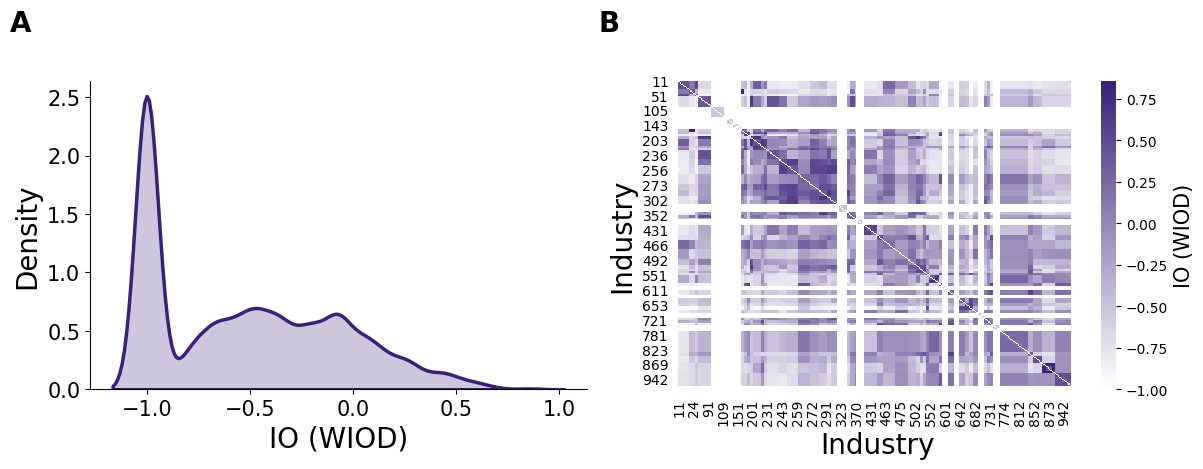

In [29]:
fig = plt.figure(figsize=(14, 4))
ax = [0]*2
gs = GridSpec(1,2, figure=fig)
ax[0] = fig.add_subplot(gs[0,0])
ax[1] = fig.add_subplot(gs[0,1])
fig.subplots_adjust(hspace=0.55, wspace=0.185) 

textsize = 20
key_var = "io_wiot_hun"
region_levels = ["nuts3", "nuts4"]

# colormap
cvals  = [-1, 1]
colors = ["#FFFFFF","#382178"]
norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)

# NUST3
reg_df = pd.read_csv(f"../data/oc15_2023_dec/04oc_data_{region_levels[0]}_{year}.csv", sep=";")
reg_df = reg_df[reg_df["ind1"] < reg_df["ind2"]]

density_plot(
    reg_df,
    key_column=key_var,
    colorway=colors[1],
    xlabel_text="IO (WIOD)",
    fontsize=textsize,
    ax=ax[0]
)

matrix_represantation(
    reg_df,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap=cmap,
    cbar_label="IO (WIOD)",
    ax=ax[1]
)

# subplot title
for a, label in zip(ax, ['A','B','C','D']):
    a.annotate(label.upper(), xy=(0,1), xycoords='axes fraction', xytext=(-80,50), textcoords='offset pixels', weight='bold', size=textsize)

# plt.savefig(f"../figures/si_{key_var}_distributions.png", dpi=300, bbox_inches='tight', facecolor="white")

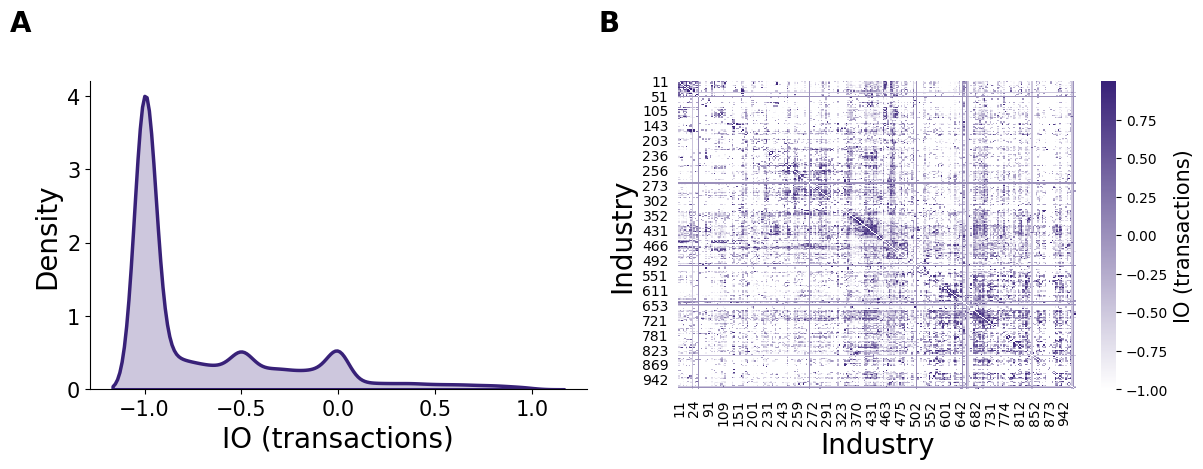

In [31]:
fig = plt.figure(figsize=(14, 4))
ax = [0]*2
gs = GridSpec(1,2, figure=fig)
ax[0] = fig.add_subplot(gs[0,0])
ax[1] = fig.add_subplot(gs[0,1])
fig.subplots_adjust(hspace=0.55, wspace=0.185) 

textsize = 20
key_var = "io_norm3"
region_levels = ["nuts3", "nuts4"]

# colormap
cvals  = [-1, 1]
colors = ["#FFFFFF","#382178"]
norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)

# NUST3
reg_df = pd.read_csv(f"../data/oc15_2023_dec/04oc_data_{region_levels[0]}_{year}.csv", sep=";")
reg_df = reg_df[reg_df["ind1"] < reg_df["ind2"]]

density_plot(
    reg_df,
    key_column=key_var,
    colorway=colors[1],
    xlabel_text="IO (transactions)",
    fontsize=textsize,
    ax=ax[0]
)

matrix_represantation(
    reg_df,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap=cmap,
    cbar_label="IO (transactions)",
    ax=ax[1]
)

# subplot title
for a, label in zip(ax, ['A','B','C','D']):
    a.annotate(label.upper(), xy=(0,1), xycoords='axes fraction', xytext=(-80,50), textcoords='offset pixels', weight='bold', size=textsize)

# plt.savefig(f"../figures/si_{key_var}_distributions.png", dpi=300, bbox_inches='tight', facecolor="white")

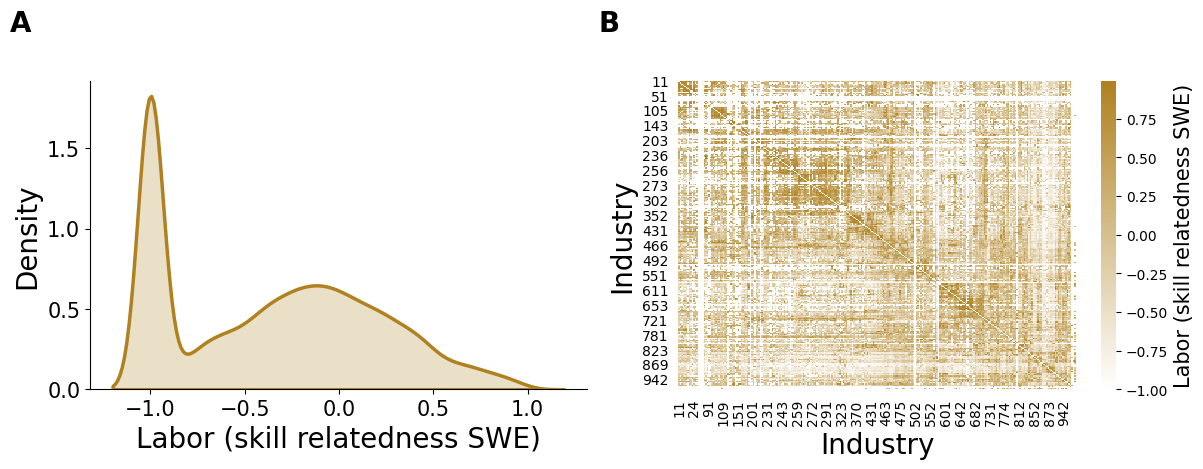

In [9]:
fig = plt.figure(figsize=(14, 4))
ax = [0]*2
gs = GridSpec(1,2, figure=fig)
ax[0] = fig.add_subplot(gs[0,0])
ax[1] = fig.add_subplot(gs[0,1])
fig.subplots_adjust(hspace=0.55, wspace=0.185) 

textsize = 20
key_var = "swe_sr_norm"
region_levels = ["nuts3", "nuts4"]

# colormap
cvals  = [-1, 1]
colors = ["#FFFFFF","#AF8120"]
norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)

# NUST3
reg_df = pd.read_csv(f"../data/oc15_2023_dec/04oc_data_{region_levels[0]}_{year}.csv", sep=";")
reg_df = reg_df[reg_df["ind1"] < reg_df["ind2"]]

density_plot(
    reg_df,
    key_column=key_var,
    colorway=colors[1],
    xlabel_text="Labor (skill relatedness SWE)",
    fontsize=textsize,
    ax=ax[0]
)

matrix_represantation(
    reg_df,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap=cmap,
    cbar_label="Labor (skill relatedness SWE)",
    ax=ax[1]
)

# subplot title
for a, label in zip(ax, ['A','B','C','D']):
    a.annotate(label.upper(), xy=(0,1), xycoords='axes fraction', xytext=(-80,50), textcoords='offset pixels', weight='bold', size=textsize)

# plt.savefig(f"../figures/si_{key_var}_distributions.png", dpi=300, bbox_inches='tight', facecolor="white")

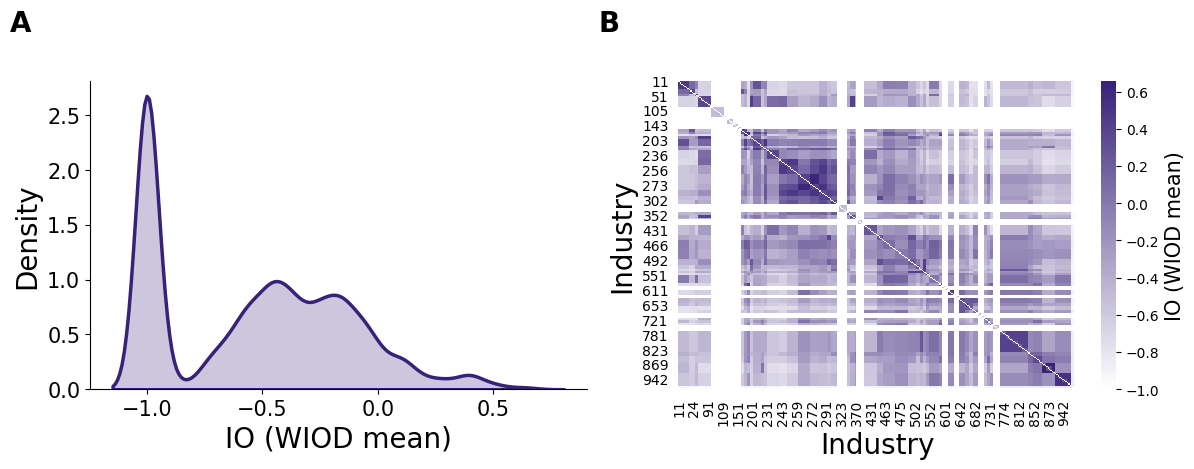

In [15]:
fig = plt.figure(figsize=(14, 4))
ax = [0]*2
gs = GridSpec(1,2, figure=fig)
ax[0] = fig.add_subplot(gs[0,0])
ax[1] = fig.add_subplot(gs[0,1])
fig.subplots_adjust(hspace=0.55, wspace=0.185) 

textsize = 20
key_var = "iv_wiot_mean"
region_levels = ["nuts3", "nuts4"]

# colormap
cvals  = [-1, 1]
colors = ["#FFFFFF","#382178"]
norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)

# NUST3
reg_df = pd.read_csv(f"../data/oc15_2023_dec/04oc_data_{region_levels[0]}_{year}.csv", sep=";")
reg_df = reg_df[reg_df["ind1"] < reg_df["ind2"]]

density_plot(
    reg_df,
    key_column=key_var,
    colorway=colors[1],
    xlabel_text="IO (WIOD mean)",
    fontsize=textsize,
    ax=ax[0]
)

matrix_represantation(
    reg_df,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap=cmap,
    cbar_label="IO (WIOD mean)",
    ax=ax[1]
)

# subplot title
for a, label in zip(ax, ['A','B','C','D']):
    a.annotate(label.upper(), xy=(0,1), xycoords='axes fraction', xytext=(-80,50), textcoords='offset pixels', weight='bold', size=textsize)

# plt.savefig(f"../figures/si_{key_var}_distributions.png", dpi=300, bbox_inches='tight', facecolor="white")

In [16]:
def correlation_matrix(data, key_columns, labels, textsize, cmap, heatmap=True, ax=None):
    """create heatmap from correlation matrix"""
    
    # only important columns
    data = data[key_columns]

    # correlation matrix
    corr_mat = round(data.corr(), 2)

    if heatmap==False:
        return corr_mat
    else:
        if ax is None:
            ax = plt.gca()
        sns.heatmap(corr_mat, cbar=False, annot=True, cmap=cmap, ax=ax)
        ax.set_xticklabels(labels, size=textsize)
        ax.set_yticklabels(labels, size=textsize)

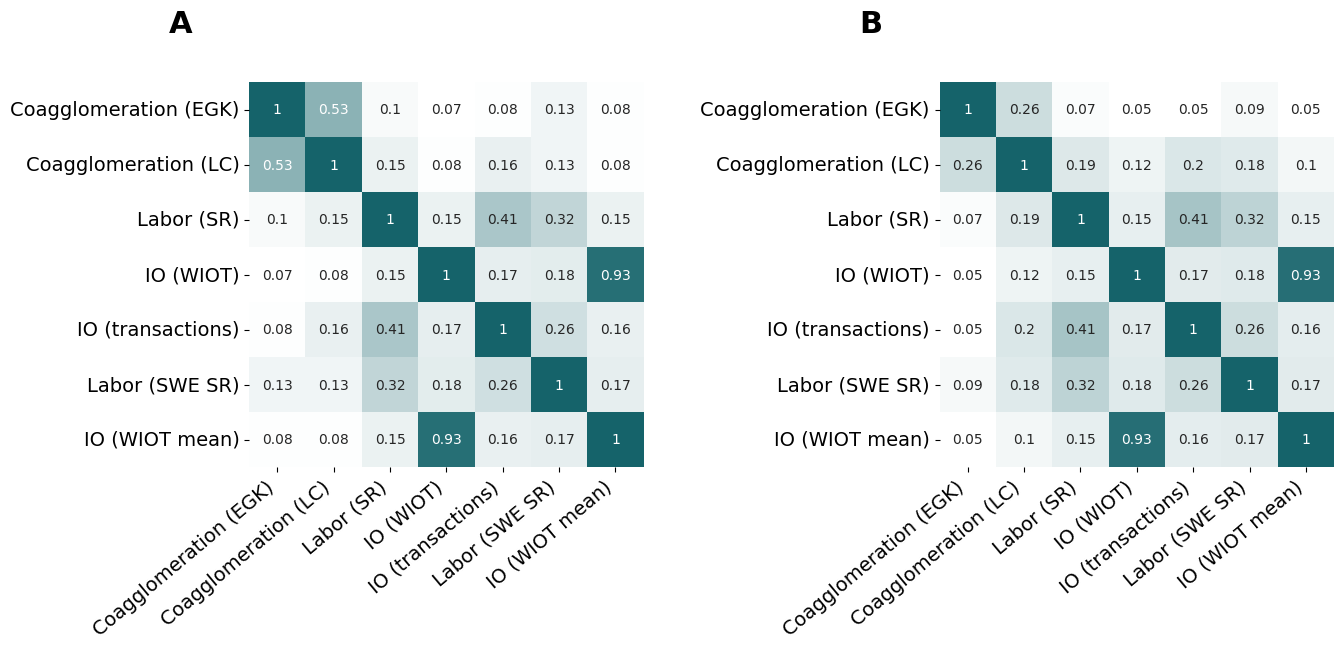

In [19]:
# correlation table
fig = plt.figure(figsize=(14, 5))
ax = [0]*2
gs = GridSpec(1,2, figure=fig)
ax[0] = fig.add_subplot(gs[0,0])
ax[1] = fig.add_subplot(gs[0,1])
fig.subplots_adjust(wspace=0.75) 

textsize = 14
key_vars = ["egk_coagg", "coagg_porter_rca01", "sr_norm", "io_norm3", "io_wiot_hun", "swe_sr_norm", "iv_wiot_mean"]
region_levels = ["nuts3", "nuts4"]

# colormap
cvals  = [0, 1]
colors = ["#FFFFFF","#15636A"]
norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)

# NUST3
reg_df = pd.read_csv(f"../data/oc15_2023_dec/04oc_data_{region_levels[0]}_{year}.csv", sep=";")
reg_df = reg_df[reg_df["ind1"] < reg_df["ind2"]]
reg_df = reg_df[key_vars]

# plot the matrix w/ style
corr_mat = reg_df.corr()

labels = ["Coagglomeration (EGK)", "Coagglomeration (LC)", "Labor (SR)", "IO (WIOT)", "IO (transactions)", "Labor (SWE SR)", "IO (WIOT mean)"]
correlation_matrix(
    reg_df,
    key_columns=["egk_coagg", "coagg_porter_rca01", "sr_norm", "io_wiot_hun", "io_norm3", "swe_sr_norm", "iv_wiot_mean"],
    labels=labels,
    textsize=textsize,
    cmap=cmap,
    heatmap=True,
    ax=ax[0]
)
ax[0].set_xticklabels(labels, size=textsize, rotation=40, ha='right')

# NUST4
reg_df = pd.read_csv(f"../data/oc15_2023_dec/04oc_data_{region_levels[1]}_{year}.csv", sep=";")
reg_df = reg_df[reg_df["ind1"] < reg_df["ind2"]]
reg_df = reg_df[key_vars]

# plot the matrix w/ style
corr_mat = reg_df.corr()

labels = ["Coagglomeration (EGK)", "Coagglomeration (LC)", "Labor (SR)", "IO (WIOT)", "IO (transactions)", "Labor (SWE SR)", "IO (WIOT mean)"]
correlation_matrix(
    reg_df,
    key_columns=["egk_coagg", "coagg_porter_rca01", "sr_norm", "io_wiot_hun", "io_norm3", "swe_sr_norm", "iv_wiot_mean"],
    labels=labels,
    textsize=textsize,
    cmap=cmap,
    heatmap=True,
    ax=ax[1]
)
ax[1].set_xticklabels(labels, size=textsize, rotation=40, ha='right')

# subplot title
for a, label in zip(ax, ['A','B','C','D']):
    a.annotate(label.upper(), xy=(0,1), xycoords='axes fraction', xytext=(-80,50), textcoords='offset pixels', weight='bold', size=textsize+8)

# plt.savefig(f"../figures/si_corr_matrix.png", dpi=300, bbox_inches='tight', facecolor="white")

**complementary plots for Figure 3 (main)**

In [7]:
# OC data in
ddf = pd.read_csv("../data/oc15_2023_dec/oc_distance_io_labor_ties.csv", sep=";")
ddf = ddf.fillna(0)

In [8]:
# re-bin distance below 50 km
factors = [10, 25, 50]
for factor in factors:
    ddf[f'dist_int{factor}'] = np.floor(ddf['dist_int'] / factor) * factor

# re-bin distance above 50 km
conditions = [
    (ddf["dist_int"] < 50),
    (ddf["dist_int"] >= 50) & (ddf["dist_int"] < 100),
    (ddf["dist_int"] >= 100) & (ddf["dist_int"] < 200),
    (ddf["dist_int"] >= 200) & (ddf["dist_int"] < 500),
    (ddf["dist_int"] >= 500),
]

choices = [
    ddf["dist_int"],
    ddf["dist_int10"],
    ddf["dist_int25"],
    ddf["dist_int50"],
    np.nan,
]

ddf["dist_combined"] = np.select(conditions, choices, default=np.nan)

In [9]:
# group by dist_combined and calculate aggregated values
agg_cols = ["poss_ties", "obs_io", "obs_labor", "obs_overlap", "nr_io_sr_ties", "io_diff_ind"]
ddf2 = ddf.groupby(["dist_combined"])[agg_cols].sum().reset_index()

# calculate probabilities
prob_cols = ["prob_io", "prob_labor", "prob_overlap"]
ddf2[prob_cols] = ddf2[["obs_io", "obs_labor", "obs_overlap"]].div(ddf2["poss_ties"], axis=0)

# calculate logs
ddf2["log_dist_combined"] = np.log10(ddf2["dist_combined"] + 1)
ddf2[[f"log_{col}" for col in prob_cols]] = ddf2[prob_cols].apply(lambda x: np.log10(x))

# standard errors for proportions sqrt(p*(1-p)/n) -- p : proportion, n : sample size
ddf2["se_io"] = np.sqrt(ddf2["prob_io"]*(1-ddf2["prob_io"]) / np.sqrt(ddf2["poss_ties"]))
ddf2["se_labor"] = np.sqrt(ddf2["prob_labor"]*(1-ddf2["prob_labor"]) / np.sqrt(ddf2["poss_ties"]))
ddf2["se_overlap"] = np.sqrt(ddf2["prob_overlap"]*(1-ddf2["prob_overlap"]) / np.sqrt(ddf2["poss_ties"]))

# calculate confidence intervals
ddf2["log_prob_labor_conf_up"] = ddf2["log_prob_labor"] - 1.96*(ddf2["se_labor"])
ddf2["log_prob_labor_conf_down"] = ddf2["log_prob_labor"] + 1.96*(ddf2["se_labor"])
ddf2["log_prob_io_conf_up"] = ddf2["log_prob_io"] - 1.96*(ddf2["se_io"])
ddf2["log_prob_io_conf_down"] = ddf2["log_prob_io"] + 1.96*(ddf2["se_io"])
ddf2["log_prob_overlap_conf_up"] = ddf2["log_prob_overlap"] - 1.96*(ddf2["se_overlap"])
ddf2["log_prob_overlap_conf_down"] = ddf2["log_prob_overlap"] + 1.96*(ddf2["se_overlap"])

/opt/homebrew/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [10]:
def tie_distance(df, distance_column, var_color_dict, fontsize, yaxis_text, legend_dict, ax=None):
    """function for different x: distance y: ties plots"""
    
    # data preparation
    all_columns = distance_column + list(var_color_dict.keys())
    df = df[all_columns]

    # figure preparation
    if ax is None:
        ax = plt.gca()
    for key, value in var_color_dict.items():
        ax.plot(df[distance_column], df[key], "o-", color=value, markersize=5, linewidth=3, label=legend_dict[key])
        ax.set_xlabel("Distance in km (log)", size=fontsize)
        ax.set_ylabel(yaxis_text, size=fontsize)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

In [11]:
# calculations for SR / no-SR supplier connections
ddf2["nr_io_no_sr_ties"] = ddf2["io_diff_ind"] - ddf2["nr_io_sr_ties"]
ddf2["nr_io_no_sr_ties_total"] = ddf2["nr_io_no_sr_ties"].sum()
ddf2["nr_io_sr_ties_total"] = ddf2["nr_io_sr_ties"].sum()

# shares
ddf2["share_io_no_sr_ties"] = ddf2["nr_io_no_sr_ties"] / ddf2["nr_io_no_sr_ties_total"]
ddf2["share_io_sr_ties"] = ddf2["nr_io_sr_ties"] / ddf2["nr_io_sr_ties_total"]

# standard errors for proportions sqrt(p*(1-p)/n) -- p : proportion, n : sample size
ddf2["se_io_no_sr"] = np.sqrt(ddf2["share_io_no_sr_ties"]*(1-ddf2["share_io_no_sr_ties"])) / np.sqrt(ddf2["nr_io_sr_ties_total"])
ddf2["share_io_no_sr_ties_ci"] = 1.96*(ddf2["se_io_no_sr"])
#ddf2["share_io_no_sr_ties_ci"] = ddf2["share_io_no_sr_ties"] - 1.96*(ddf2["se_io_no_sr"])
#ddf2["share_io_no_sr_ties_L"] = ddf2["share_io_no_sr_ties"] + 1.96*(ddf2["se_io_no_sr"])

ddf2["se_io_sr"] = np.sqrt(ddf2["share_io_sr_ties"]*(1-ddf2["share_io_sr_ties"])) / np.sqrt(ddf2["nr_io_sr_ties_total"])
ddf2["share_io_sr_ties_ci"] = 1.96*(ddf2["se_io_sr"])
#ddf2["share_io_no_sr_ties_L"] = ddf2["share_io_no_sr_ties"] + 1.96*(ddf2["se_for_plot"])


/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_65356/3751481569.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(["", "$10^0$", "", "", "", "$10^1$", "", "", "", "$10^2$", ""], size=fontsize-2)


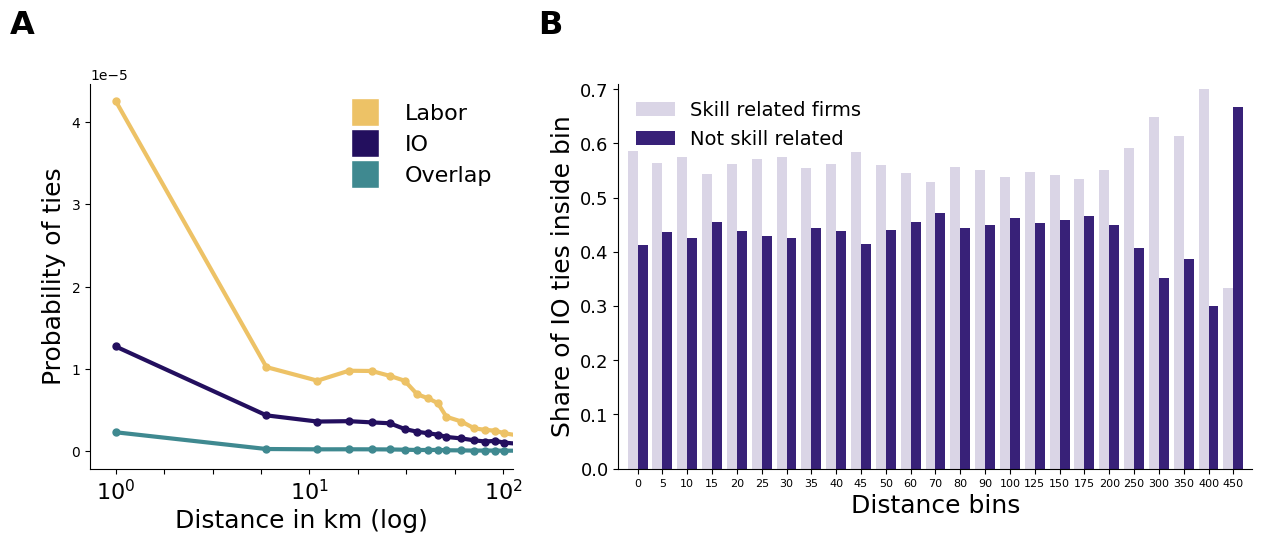

In [14]:
#limited_df = ddf2[ddf2["dist_combined"] <= 25]
ddf2["share_io_sr_indist"] = ddf2["nr_io_sr_ties"] / ddf2["io_diff_ind"]
ddf2["share_io_no_sr_indist"] = ddf2["nr_io_no_sr_ties"] / ddf2["io_diff_ind"]
ddf2["dist_combined"] = ddf2["dist_combined"].astype(int)

fig, ax = plt.subplots(1,2, figsize=(15,5), width_ratios=[1, 1.5])

fontsize = 18



# A -- probability of ties
color_dict = {"prob_labor":"#EDC266", "prob_io":"#230F5E", "prob_overlap":"#3F8990"}
legend_text = {"prob_labor":"Labor", "prob_io":"IO", "prob_overlap":"Labor and IO"}
tie_distance(
    ddf2,
    distance_column=["log_dist_combined"],
    var_color_dict=color_dict,
    fontsize=fontsize,
    yaxis_text="Probability of ties",
    legend_dict=legend_text,
    ax=ax[0]
)
ax[0].set_xlim(-0.13270882709389803, 2.05)
ax[0].set_xticklabels(["", "$10^0$", "", "", "", "$10^1$", "", "", "", "$10^2$", ""], size=fontsize-2)

# ax[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '{:,.000f}'.format(x)))

#print(ax[0].get_xlim())
#ax[0].set_ylim(-7.75, -4.15)
#ax[0].set_yticklabels(["", "", "$10^{-7}$", "", "$10^{-6}$", "", "$10^{-5}$", ""], size=fontsize-2)
ax[0].legend(loc="upper right", prop={'size': fontsize-4}, frameon=False)

custom_legend = [
    plt.Line2D([0], [0], marker="s", color='w', markerfacecolor="#EDC266", markersize=20),
    plt.Line2D([0], [0], marker="s", color='w', markerfacecolor="#230F5E", markersize=20),
    plt.Line2D([0], [0], marker="s", color='w', markerfacecolor="#3F8990", markersize=20)
]
ax[0].legend(custom_legend, ["Labor", "IO", "Overlap"], loc="upper right", prop={'size': fontsize-2}, frameon=False)




# B 
bar_width = 0.40
index = np.arange(len(ddf2["dist_combined"]))
ax[1].bar(
        index,
        ddf2["share_io_sr_indist"],
        bar_width,
        label="Skill related firms",
        #yerr=[limited_df["share_io_sr_ties_ci"], limited_df["share_io_sr_ties_ci"]],
        capsize=0,
        #color="#EDC266"
        #color="#e6e3ed"
        color="#dad5e6"
)
ax[1].bar(
        index + bar_width,
        ddf2["share_io_no_sr_indist"],
        bar_width,
        label="Not skill related",
        #yerr=[limited_df["share_io_no_sr_ties_ci"], limited_df["share_io_no_sr_ties_ci"]],
        capsize=0,
        color="#382178"
)
ax[1].set_xlabel("Distance bins", size=fontsize)
ax[1].set_xticks(index + bar_width / 2, ddf2["dist_combined"], size=fontsize-10)
ax[1].tick_params("y", labelsize=(fontsize-5))
ax[1].margins(0.015, tight=True)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].set_ylabel("Share of IO ties inside bin", size=fontsize)
ax[1].legend(loc="upper left", prop={'size': fontsize-4}, frameon=False)

# subplot title
for a, label in zip(ax, ['A','B','C','D']):
    a.annotate(label.upper(), xy=(0,1), xycoords='axes fraction', xytext=(-80,50), textcoords='offset pixels', weight='bold', size=fontsize+5)

# plt.savefig(f"../figures/mf03_gravity_share_sr.png", dpi=300, bbox_inches='tight', facecolor="white")

0     4.259033e-05
1     1.021431e-05
2     8.560952e-06
3     9.769763e-06
4     9.739247e-06
5     9.146854e-06
6     8.559985e-06
7     6.911455e-06
8     6.414927e-06
9     5.836342e-06
10    4.167151e-06
11    3.584852e-06
12    2.761086e-06
13    2.568675e-06
14    2.476434e-06
15    2.171860e-06
16    1.800133e-06
17    1.618946e-06
18    1.768500e-06
19    1.161460e-06
20    6.981914e-07
21    5.878430e-07
22    6.481143e-07
23    6.042574e-07
24    4.329624e-07
Name: prob_labor, dtype: float64

In [ ]:
# figure A -- NO LOG version of Figure 3a
# figure B -- out of all ties in distance bin, number of ties that are skill related

**Visualize betas from regressions**

In [3]:
# estimates IN
betas_df = pd.read_csv("../outputs/betas_io_labor.csv", sep=";")
betas_df = betas_df[betas_df["variable"] != "(Intercept)"]

In [4]:
#betas_group = betas_df.groupby(["ind_group", "ind_group_color", "variable"]).agg(
betas_group = betas_df.groupby(["ind2dig", "variable"]).agg(
    avg_beta = pd.NamedAgg("beta", "mean")
).reset_index()

In [5]:
betas_group = betas_group.pivot(index="ind2dig", columns='variable', values='avg_beta').reset_index()

# rename columns if needed
betas_group.columns.name = None
betas_group.columns = ['ind_group', 'io_wiot_hun_stand', 'lab_stand']

In [6]:
betas_group

,ind_group,io_wiot_hun_stand,lab_stand
0,1,0.036818,0.072737
1,2,0.002413,0.037576
2,3,0.041824,0.034675
3,5,0.069635,-0.016351
4,6,0.081729,-0.206210
...,...,...,...
72,92,0.058110,-0.001765
73,93,-0.015263,0.006383
74,94,0.025819,0.167092
75,95,0.007068,0.017788


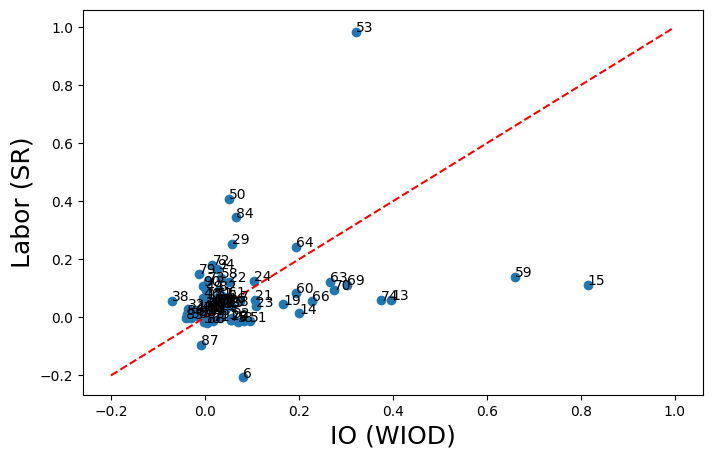

In [12]:
fig, ax = plt.subplots(1,1, figsize=(8,5))
ax.scatter(x=betas_group["io_wiot_hun_stand"], y=betas_group["lab_stand"])
ax.plot([-0.2, 1], [-0.2, 1], linestyle='--', color='red', label='45-degree line')
ax.set_xlabel("IO (WIOD)", size=18)
ax.set_ylabel("Labor (SR)", size=18)

for i, label in enumerate(betas_group["ind_group"]):
    ax.text(betas_group['io_wiot_hun_stand'][i], betas_group['lab_stand'][i], label)

In [6]:
betas_group.head(2)

,ind2dig,variable,avg_beta
0,1,io_wiot_hun_stand,0.036818
1,1,lab_stand,0.072737


In [7]:
betas_group = betas_group.pivot(index='ind_group', columns='variable', values='avg_beta').reset_index()

# rename columns if needed
betas_group.columns.name = None
betas_group.columns = ['ind_group', 'io_wiot_hun_stand', 'lab_stand']

KeyError: 'ind_group'

In [173]:
betas_group

,ind_group,io_wiot_hun_stand,lab_stand
0,1,0.043317,0.018102
1,2,0.079216,0.050679
2,3,-0.016464,0.039447
3,4,0.008601,0.033741
4,5,-0.008802,0.035889
5,6,0.136598,0.192699
6,7,0.002411,0.005227
7,8,0.211460,0.149956
8,9,0.195329,0.088393
9,10,0.020514,0.053092


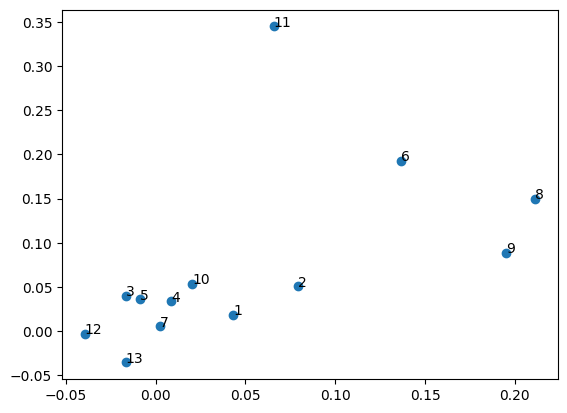

In [174]:
plt.scatter(betas_group["io_wiot_hun_stand"], betas_group["lab_stand"])

for i, label in enumerate(betas_group["ind_group"]):
    plt.text(betas_group['io_wiot_hun_stand'][i], betas_group['lab_stand'][i], label)